In [111]:
# !pip install tqdm

import numpy as np
import os
from tqdm import tqdm


In [182]:
IMAGE_PATH = "../data/processed/images/ngc628_f770w_norm.npy"
MASK_PATH = "../data/processed/masks/ngc628_f770w_norm_mask.npy"
OUTPUT_DIR = "../data/processed/patches"


PATCH_SIZE = 256
STRIDE = 128  # liitle overlap 

# THRESHOLD = 0.05
LOW_THRESHOLD = 0.001   # negative patch threshold
HIGH_THRESHOLD = 0.05   # positive patch threshold


In [132]:
image = np.load(IMAGE_PATH).astype(np.float32)
mask = np.load(MASK_PATH).astype(np.float32)

# Ensuring binary mask
mask = (mask > 0).astype(np.float32)

In [131]:
# small sanity check
print("Image shape:", image.shape, "dtype:", image.dtype, "min/max:", image.min(), image.max())
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "min/max:", mask.min(), mask.max())
print("Bubble pixels:", int(mask.sum()))

unique_vals = np.unique(mask)
print("Mask unique values:", unique_vals[:10])

Image shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Mask shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Bubble pixels: 362638
Mask unique values: [0. 1.]


In [133]:
assert image.shape == mask.shape, "Image and mask must have the same height and width."
assert image.ndim == 2, "Expected image to be a 2D array."
assert mask.ndim == 2, "Expected mask to be a 2D array."
assert mask.max() <= 1 and mask.min() >= 0, "Mask must be binary or in [0, 1]."
# assert mask.sum() > 0, "Mask contains no bubble pixels"

In [134]:
image = image.astype(np.float32)

# for Training image
denom = image.max() - image.min()
if denom > 0:
    image = (image - image.min()) / denom
else:
    image = np.zeros_like(image)

In [185]:
def extract_patches(image, mask, patch_size=256, stride=128, low_threshold=0.009, high_threshold=0.01):
    H, W = image.shape

    pos_patches = []
    weak_patches = []
    neg_patches = []

    # adding "+1" to include edge patches
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            
            img_patch = image[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            bubble_ratio = np.sum(mask_patch) / (patch_size**2)

            if bubble_ratio >= high_threshold:
                pos_patches.append((img_patch, mask_patch))
            elif bubble_ratio >= low_threshold:
                weak_patches.append((img_patch, mask_patch))
            else:
                neg_patches.append((img_patch, mask_patch))
    
    return pos_patches, weak_patches, neg_patches

In [183]:
np.random.seed(42)

pos, weak, neg = extract_patches(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD)

print(f"Positive patches: {len(pos)}")
print(f"Weak patches: {len(weak)}")
print(f"Negative patches: {len(neg)}")

# Balancing
np.random.shuffle(neg)

if len(pos)>len(neg):
    pos = pos[:len(neg)]  
else: 
    neg = neg[:len(pos)]

dataset = pos + neg
np.random.shuffle(dataset)

dataset = pos + neg

print(f"Dataset: {len(dataset)}")

Positive patches: 123
Negative patches: 13
Dataset: 26


In [190]:
np.random.shuffle(pos)
np.random.shuffle(weak)
np.random.shuffle(neg)

n_strong = len(pos)
n_weak = min(len(weak), n_strong)
n_neg = min(len(neg), n_strong // 2)

dataset = pos + weak[:n_weak] + neg[:n_neg]

np.random.shuffle(dataset)

In [192]:
print(f"Positive patches: {len(pos)}")
print(f"Weak patches: {len(weak)}")
print(f"Negative patches: {len(neg)}")

print(f"Dataset: {len(dataset)}")

Positive patches: 99
Weak patches: 22
Negative patches: 15
Dataset: 136


In [193]:
X = np.array([d[0] for d in dataset], dtype=np.float32)
Y = np.array([d[1] for d in dataset], dtype=np.float32)

# Adding channel dimension for CNN
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

assert X.shape == Y.shape
assert X.ndim == 4
assert Y.ndim == 4

X shape: (136, 256, 256, 1)
Y shape: (136, 256, 256, 1)


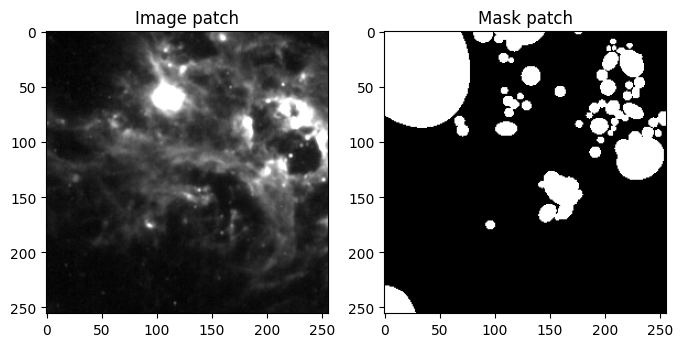

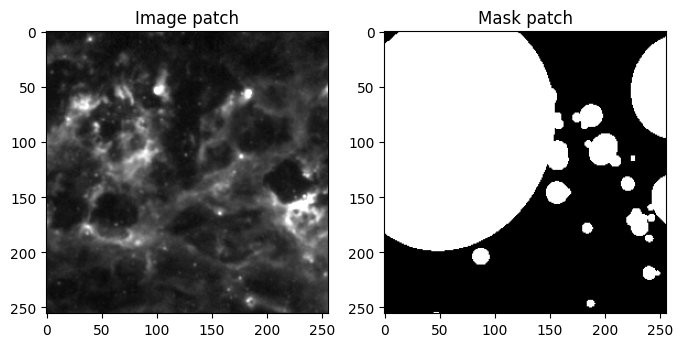

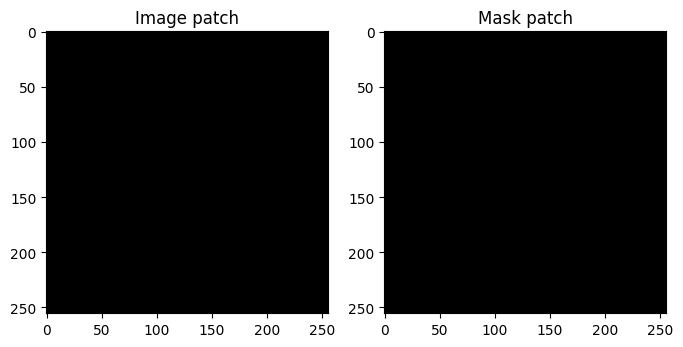

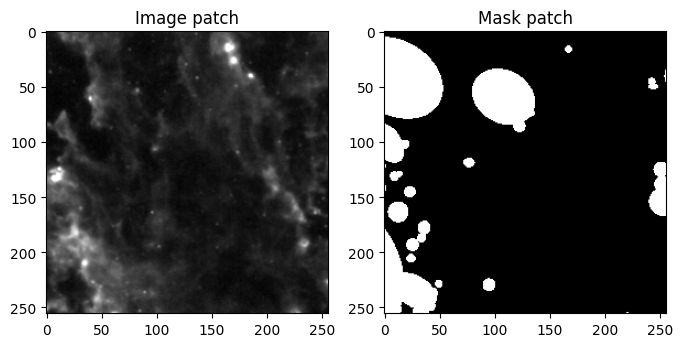

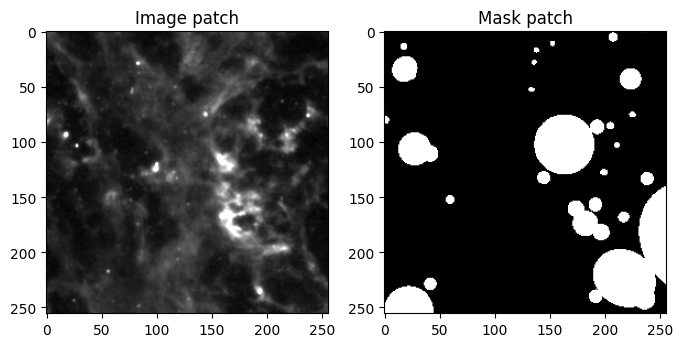

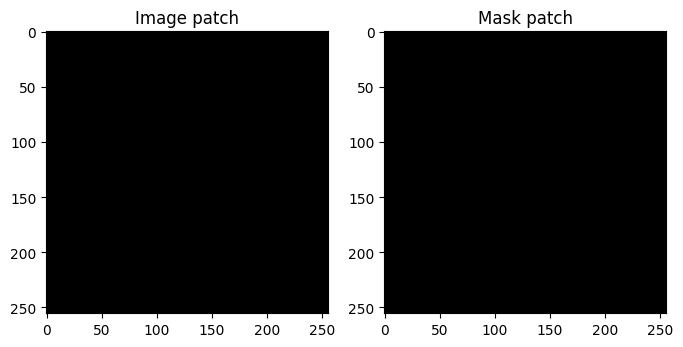

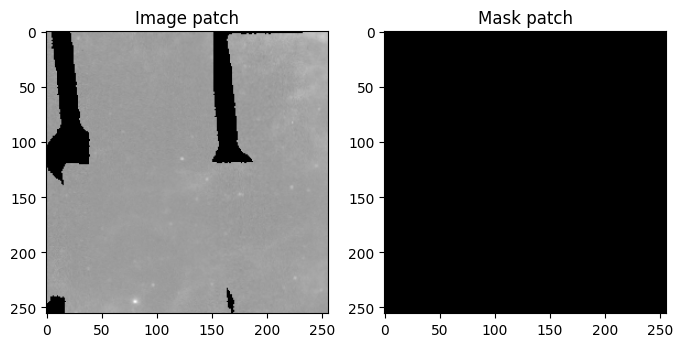

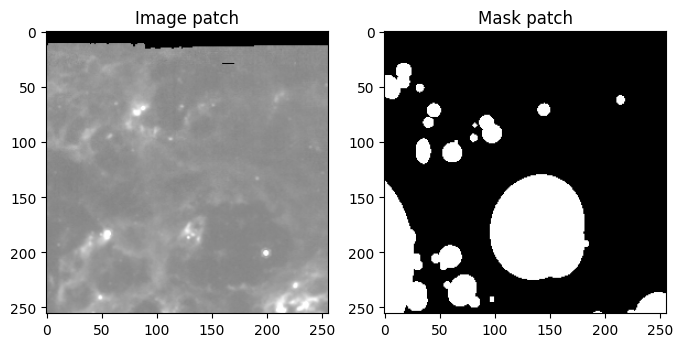

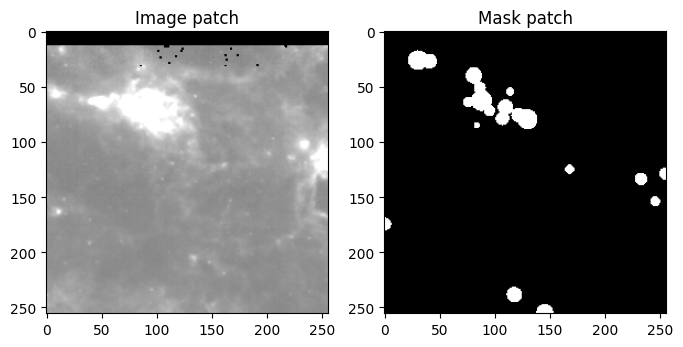

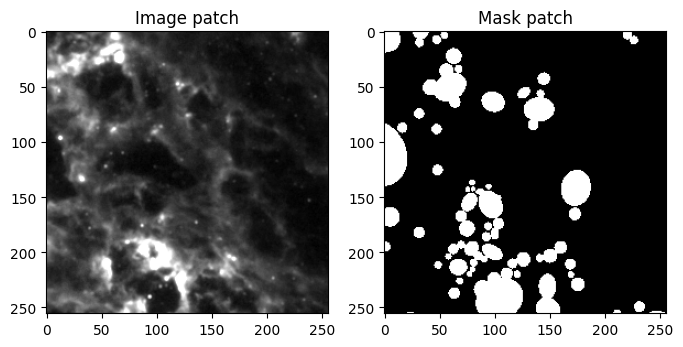

In [194]:
# sanity check

for i in range(10):
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Image patch")

    plt.subplot(1,2,2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask patch")

    plt.show()

In [195]:
os.makedirs("../data/processed/patches", exist_ok=True)

np.save("../data/processed/patches/X.npy", X)
np.save("../data/processed/patches/Y.npy", Y)

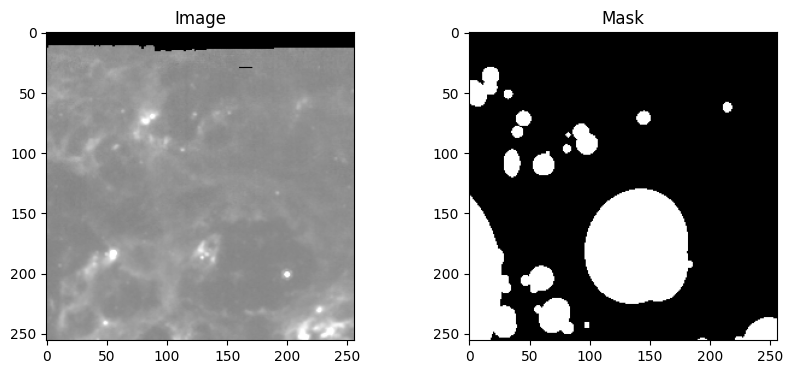

In [205]:
# visual sanity check

import matplotlib.pyplot as plt

idx = np.random.randint(0, len(X))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(X[idx].squeeze(), cmap='gray')
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[idx].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()